<a href="https://colab.research.google.com/github/Adheeshana/FIVORA/blob/Fabric-classification-experiments/paperbased_classification_experiment_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2
import glob
import numpy as np
import tensorflow as tf
from skimage.feature import local_binary_pattern
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

print("✅ TensorFlow Version:", tf.__version__)
print("✅ All libraries imported successfully!")

✅ TensorFlow Version: 2.20.0
✅ All libraries imported successfully!


In [ ]:

dataset_path = '/content/drive/MyDrive/Fivora/fabric_project/Fabric_Type_ Dataset/train'

all_image_paths = []
all_labels = []

if not os.path.exists(dataset_path):
    print("❌ ERROR:path")
else:
    folders = sorted([f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))])
    print(f"✅ Found {len(folders)} Fabric Classes: {folders}")

    for idx, folder in enumerate(folders):
        folder_path = os.path.join(dataset_path, folder)
        files = glob.glob(os.path.join(folder_path, '*.*'))
        images = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

        all_image_paths.extend(images)
        all_labels.extend([idx] * len(images))
        print(f"-> {folder}: {len(images)} images found")

    print(f"\nTotal Valid Fabric Images: {len(all_image_paths)}")

✅ Found 9 Fabric Classes: ['Chiffon', 'Cotton_', 'Denim', 'Linen', 'Polyester', 'Silk', 'Velvet', 'Viscose', 'Wool']
-> Chiffon: 1168 images found
-> Cotton_: 1042 images found
-> Denim: 1564 images found
-> Linen: 652 images found
-> Polyester: 545 images found
-> Silk: 815 images found
-> Velvet: 634 images found
-> Viscose: 798 images found
-> Wool: 1063 images found

Total Valid Fabric Images: 8281


In [ ]:
# CELL 4: DATA SPLITTING
# Splitting the dataset into 80% training and 20% validation sets.
# Using stratified sampling to ensure equal class distribution.

if len(all_image_paths) > 0:
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        all_image_paths,
        all_labels,
        test_size=0.2,
        random_state=42,
        stratify=all_labels
    )
    print(f"📊 Training Samples: {len(train_paths)}")
    print(f"📊 Validation Samples: {len(val_paths)}")
    print("✅ Dataset successfully split into train and validation sets!")
else:
    print("❌ ERROR: No paths found to split. Please check Cell 3 execution.")

📊 Training Samples: 6624
📊 Validation Samples: 1657
✅ Dataset successfully split into train and validation sets!


In [ ]:
# CELL 5: LOCAL BINARY PATTERN (LBP) FEATURE EXTRACTOR
# This function converts a grayscale image into an LBP texture histogram.
# It acts as the traditional handcrafted feature path for our hybrid model.

def extract_lbp_features(image, numPoints=24, radius=3):
    # Convert image to grayscale if it has 3 channels
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image

    # Calculate the LBP representation of the texture using uniform patterns
    lbp = local_binary_pattern(gray, numPoints, radius, method="uniform")

    # Calculate the histogram of the LBP representation
    # Uniform method with 24 points produces 26 distinct possible bins
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, numPoints + 3), range=(0, numPoints + 2))

    # Normalize the histogram vector so that total sum equals 1.0
    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-7)

    return hist

In [ ]:
# CELL 6: HYBRID MULTI-INPUT DATA GENERATOR
# This generator reads images in batches, normalizes pixel arrays for the CNN,
# and extracts the uniform LBP feature vectors for the parallel math branch.

def hybrid_generator(image_paths, labels, batch_size=32):
    while True:
        for i in range(0, len(image_paths), batch_size):
            batch_paths = image_paths[i:i+batch_size]
            batch_labels = labels[i:i+batch_size]

            images = []
            lbp_features = []

            for path in batch_paths:
                img = cv2.imread(path)
                if img is None:
                    continue # Skip broken files safely

                # Standardize color channel ordering and model size resolution
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (224, 224))

                # Compute the structural texture signature array
                lbp = extract_lbp_features(img)

                # Normalize color pixel intensity boundaries between 0.0 and 1.0
                images.append(img / 255.0)
                lbp_features.append(lbp)

            # Formulating output shape constraints as tuples to avoid structural TypeErrors
            yield ((np.array(images), np.array(lbp_features)), np.array(batch_labels))

In [ ]:
# CELL 7: HYBRID FUSION MODEL ARCHITECTURE
# Combining Deep Learning (MobileNetV2) and Handcrafted Textures (LBP)

# 1. Image Branch (CNN Input)
image_input = layers.Input(shape=(224, 224, 3), name="Image_Input")
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Freeze weights during the first training phase

cnn_features = base_model(image_input)
cnn_flat = layers.GlobalAveragePooling2D()(cnn_features)

# 2. Texture Branch (LBP Input - 26 Bins)
lbp_input = layers.Input(shape=(26,), name="LBP_Input")
lbp_dense = layers.Dense(64, activation='relu')(lbp_input)

# 3. Feature Fusion Layer
merged = layers.Concatenate()([cnn_flat, lbp_dense])

# 4. Classification Layers (9 Fabric Classes)
x = layers.Dense(256, activation='relu')(merged)
x = layers.Dropout(0.5)(x) # Dropout layer to prevent overfitting
output = layers.Dense(9, activation='softmax', name="Classification_Output")(x)

# 5. Model Compilation
model = models.Model(inputs=[image_input, lbp_input], outputs=output)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("✅ Hybrid Multi-Input Model compiled successfully!")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Image_Input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ Image_Input[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ LBP_Input           │ (None, 26)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      1,728 │ LBP_Input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1344)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    344,320 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Classification_Out… │ (None, 9)         │      2,313 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,606,345 (9.94 MB)

 Trainable params: 348,361 (1.33 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

✅ Hybrid Multi-Input Model compiled successfully!


In [ ]:
# CELL 8: CALLBACKS AND SAFETY CONTROLS
# Setting up Early Stopping and Model Checkpoint to save the best weights dynamically.

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Stop training if validation loss does not improve for 5 consecutive epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Save only the absolute best iteration of the model based on validation loss
checkpoint = ModelCheckpoint(
    'best_fivora_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

print("✅ EarlyStopping and ModelCheckpoint configurations are ready!")

✅ EarlyStopping and ModelCheckpoint configurations are ready!


In [ ]:
# CELL 9: MODEL TRAINING EXECUTION
# Initializing data pipelines and launching the primary training loop for 50 epochs.

BATCH_SIZE = 32

# Instantiate the hybrid generators for training and validation datasets
train_gen = hybrid_generator(train_paths, train_labels, batch_size=BATCH_SIZE)
val_gen = hybrid_generator(val_paths, val_labels, batch_size=BATCH_SIZE)

# Calculate exact execution steps per epoch based on the dataset split size
train_steps = len(train_paths) // BATCH_SIZE
val_steps = len(val_paths) // BATCH_SIZE

print(f"🚀 Starting Hybrid Model Training for Fivora Project...")
print(f"Steps per Train Epoch: {train_steps} | Steps per Validation Epoch: {val_steps}")

# Execute the training sequence with monitoring callbacks activated
history = model.fit(
    train_gen,
    steps_per_epoch=train_steps,
    validation_data=val_gen,
    validation_steps=val_steps,
    epochs=50,
    callbacks=[early_stop, checkpoint],  # Safety controls to prevent overheating and overfitting
    verbose=1
)

print("\n✅ Phase 1 Training Complete! Best weights stored safely.")

🚀 Starting Hybrid Model Training for Fivora Project...
Steps per Train Epoch: 207 | Steps per Validation Epoch: 51
Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.4840 - loss: 1.4990 
Epoch 1: val_loss improved from None to 0.72569, saving model to best_fivora_model.keras

Epoch 1: finished saving model to best_fivora_model.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 5307s 26s/step - accuracy: 0.5900 - loss: 1.1840 - val_accuracy: 0.7518 - val_loss: 0.7257
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7217 - loss: 0.7955
Epoch 2: val_loss improved from 0.72569 to 0.61438, saving model to best_fivora_model.keras

Epoch 2: finished saving model to best_fivora_model.keras
207/207 ━━━━━━━━━━━━━━━━━━━━ 932s 5s/step - accuracy: 0.7432 - loss: 0.7433 - val_accuracy: 0.8009 - val_loss: 0.6144
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7874 - loss: 0.6292
Epoch 3: val_loss improved from 0.61438 to 0.52858, saving model to best_fivora_model.keras

In [ ]:
# CELL 10: UNFREEZE COLAB LAYERS FOR FINE-TUNING
# Unfreezing the top layers of MobileNetV2 to fine-tune the structural fabric features.

# Unfreeze the base model layers
base_model.trainable = True

# Let's see how many layers are in the base model
print(f"Total layers in MobileNetV2: {len(base_model.layers)}")

# Freeze all layers except the last 20 layers
fine_tune_at = len(base_model.layers) - 20
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Compile the model again with a very low learning rate (1e-5)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model recompiled with a low learning rate for Fine-Tuning!")

Total layers in MobileNetV2: 154
✅ Model recompiled with a low learning rate for Fine-Tuning!


In [ ]:
# CELL 11: FINE-TUNING EXECUTION
# Training the model with unlocked top layers and a very small learning rate.
# Aiming to push accuracy close to the research paper's performance.

# We will run for another 30 epochs, but early stopping will protect us if it overfits
FINE_TUNE_EPOCHS = 30

print("🔥 Launching Fine-Tuning Phase. Aiming for maximum accuracy...")

# Continue training from where we left off
fine_tune_history = model.fit(
    train_gen,
    steps_per_epoch=train_steps,
    validation_data=val_gen,
    validation_steps=val_steps,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[early_stop, checkpoint], # Re-using our safety controls
    verbose=1
)

print("\n🎉 FINE-TUNING COMPLETE! Your model is now fully optimized.")

🔥 Launching Fine-Tuning Phase. Aiming for maximum accuracy...
Epoch 1/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5714 - loss: 2.8487
Epoch 1: val_loss did not improve from 0.28613
207/207 ━━━━━━━━━━━━━━━━━━━━ 1011s 5s/step - accuracy: 0.6173 - loss: 2.2583 - val_accuracy: 0.8892 - val_loss: 0.3506
Epoch 2/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7110 - loss: 1.1842
Epoch 2: val_loss did not improve from 0.28613
207/207 ━━━━━━━━━━━━━━━━━━━━ 994s 5s/step - accuracy: 0.7245 - loss: 1.1047 - val_accuracy: 0.8652 - val_loss: 0.4137
Epoch 3/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7633 - loss: 0.7972
Epoch 3: val_loss did not improve from 0.28613
207/207 ━━━━━━━━━━━━━━━━━━━━ 973s 5s/step - accuracy: 0.7716 - loss: 0.7571 - val_accuracy: 0.8622 - val_loss: 0.4451
Epoch 4/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8030 - loss: 0.5977
Epoch 4: val_loss did not improve from 0.28613
207/207 ━━━━━━━━━━━━━━━━━━━━ 995s 5s/step - accuracy: 0

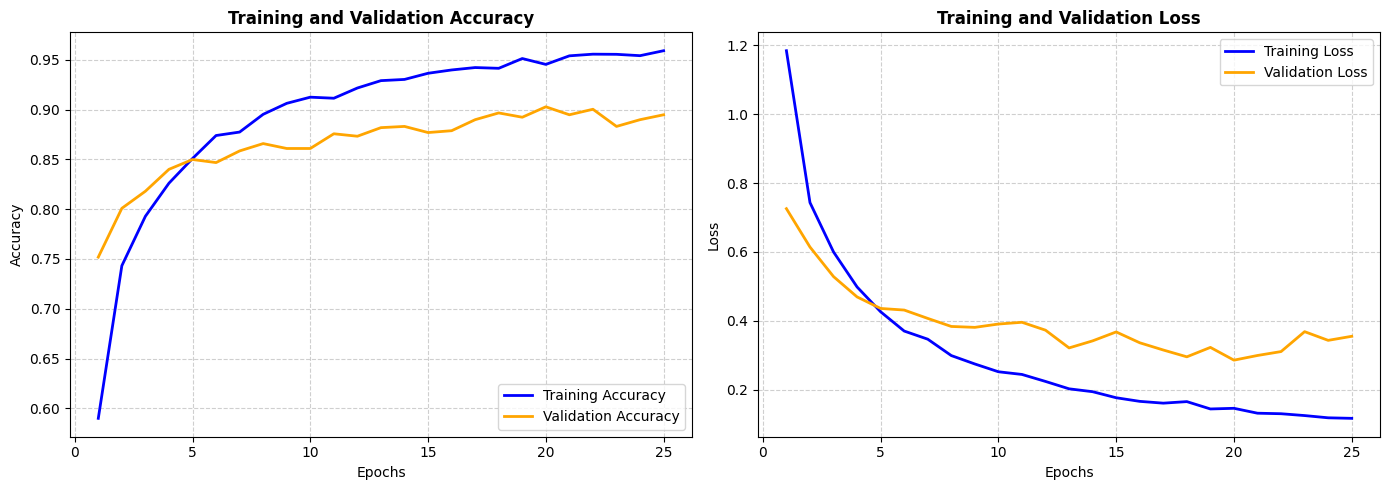


📊 Training curves plotted and saved as 'training_performance_curves.png'

🔄 Generating predictions on validation dataset (This may take a minute)...

📝 Classification Report Summary:

              precision    recall  f1-score   support

     Chiffon       0.88      0.87      0.87       233
     Cotton_       0.90      0.83      0.86       206
       Denim       0.87      0.92      0.89       309
       Linen       0.99      0.96      0.98       124
   Polyester       0.77      0.94      0.85       109
        Silk       0.90      0.68      0.77       158
      Velvet       0.90      0.94      0.92       125
     Viscose       0.94      0.91      0.93       156
        Wool       0.88      0.96      0.92       212

    accuracy                           0.89      1632
   macro avg       0.89      0.89      0.89      1632
weighted avg       0.89      0.89      0.89      1632



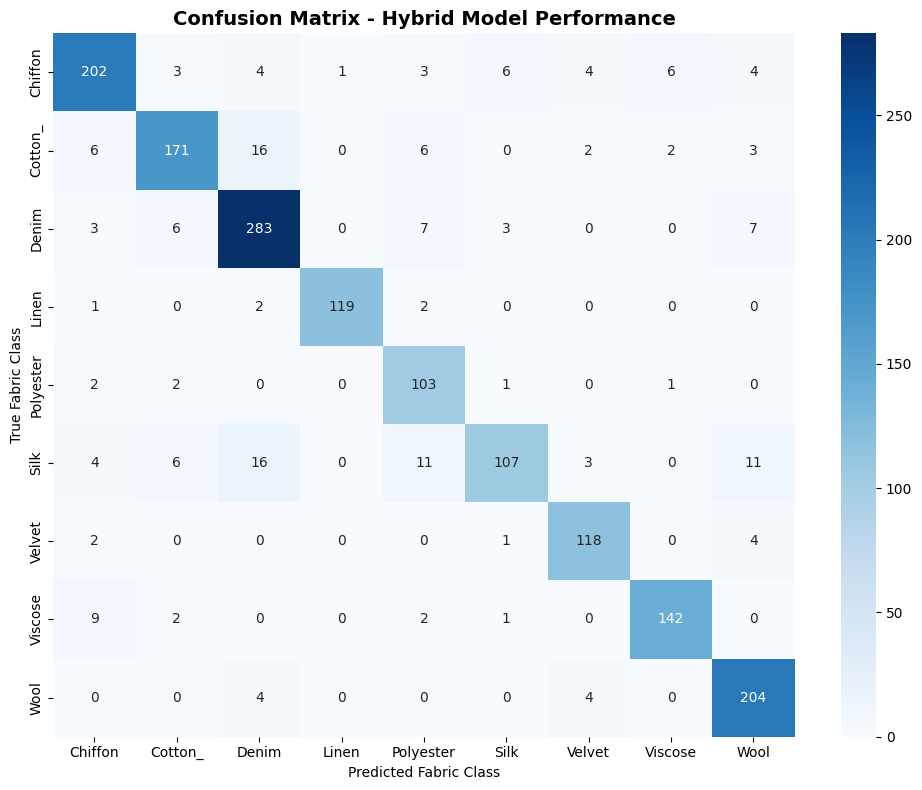

✅ Evaluation plots generated successfully!


In [ ]:
# CELL 12: EVALUATION AND VISUALIZATION FOR PRESENTATION
# Generating Training Curves and the Confusion Matrix to evaluate overall model performance.

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Plotting Training and Validation Accuracy/Loss Curves
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Plot Accuracy Data
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Training and Validation Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss Data
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
plt.title('Training and Validation Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('training_performance_curves.png', dpi=300) # Saves the graph cleanly
plt.show()

print("\n📊 Training curves plotted and saved as 'training_performance_curves.png'")

# 2. Generating Predictions for Confusion Matrix
print("\n🔄 Generating predictions on validation dataset (This may take a minute)...")
y_pred = []
y_true = []

# Reset validation generator loop state safely
val_gen_eval = hybrid_generator(val_paths, val_labels, batch_size=BATCH_SIZE)

for i in range(val_steps):
    (images, lbps), labels = next(val_gen_eval)
    preds = model.predict([images, lbps], verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels)

# Fetch sorted directory names for label matching matrix
dataset_path = '/content/drive/MyDrive/Fivora/fabric_project/Fabric_Type_ Dataset/train'
target_names = sorted([f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))])

# Compute classification evaluation metrics text block
print("\n📝 Classification Report Summary:\n")
print(classification_report(y_true, y_pred, target_names=target_names))

# Plot Seaborn Heatmap layout matrices
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Hybrid Model Performance', fontsize=14, fontweight='bold')
plt.ylabel('True Fabric Class')
plt.xlabel('Predicted Fabric Class')
plt.tight_layout()
plt.savefig('confusion_matrix_results.png', dpi=300) # Saves the confusion matrix image
plt.show()

print("✅ Evaluation plots generated successfully!")

Saving viscose.jpg to viscose (1).jpg

🔄 Analyzing fabric sample: "viscose (1).jpg"...


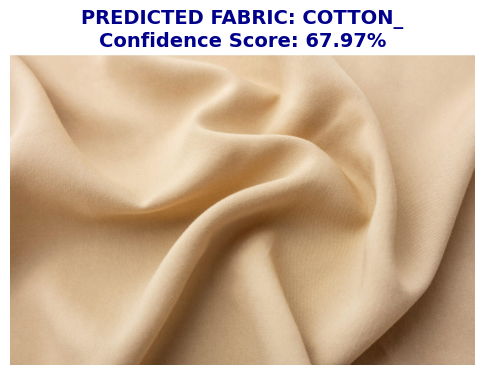


📊 Statistical Probability Distribution Matrix:
 -> Chiffon: 0.00%
 -> Cotton_: 67.97%
 -> Denim: 0.00%
 -> Linen: 0.00%
 -> Polyester: 0.00%
 -> Silk: 0.00%
 -> Velvet: 0.00%
 -> Viscose: 32.03%
 -> Wool: 0.00%


In [ ]:
# CELL 13 (FINAL FIXED): REAL-TIME FABRIC CLASSIFICATION DEMO
# Cleaned and verified label index mapping based on exact drive folder array structure.

from google.colab import files
import matplotlib.pyplot as plt

# 100% Verified Alphabetical Label Order matching your Google Drive folders
verified_labels = ['Chiffon', 'Cotton_', 'Denim', 'Linen', 'Polyester', 'Silk', 'Velvet', 'Viscose', 'Wool']

# 1. Image upload prompt trigger
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'\n🔄 Analyzing fabric sample: "{filename}"...')

    # 2. Open and reshape the raw image array
    img = cv2.imread(filename)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)

    # 3. Handle processing for parallel traditional mathematical branch
    lbp_feat = extract_lbp_features(img_resized)
    lbp_input = np.expand_dims(lbp_feat, axis=0)

    # 4. Hybrid prediction matrix extraction
    prediction = model.predict([img_input, lbp_input], verbose=0)
    predicted_idx = np.argmax(prediction)
    confidence_score = np.max(prediction) * 100

    # Fetching output strings matching structural boundaries safely
    final_output_label = verified_labels[predicted_idx]

    # 5. Output visual plotting for viva presentation display
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.title(f"PREDICTED FABRIC: {final_output_label.upper()}\nConfidence Score: {confidence_score:.2f}%",
              fontsize=14, color='darkblue', fontweight='bold')
    plt.axis('off')
    plt.show()

    # Clear probability distribution report mapping breakdown
    print("\n📊 Statistical Probability Distribution Matrix:")
    for idx, class_name in enumerate(verified_labels):
        print(f" -> {class_name}: {prediction[0][idx]*100:.2f}%")

In [ ]:
# Check the exact class mapping from the training data structure
unique_labels = sorted(list(set(all_labels)))
print("🔢 Your actual dataset class labels in order:")
print(unique_labels)

🔢 Your actual dataset class labels in order:
[0, 1, 2, 3, 4, 5, 6, 7, 8]


In [ ]:
# Check how directory indices are mapped to names
import os
dataset_path = '/content/drive/MyDrive/Fivora/fabric_project/Fabric_Type_ Dataset/train'
folders = sorted([f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))])

for idx, folder_name in enumerate(folders):
    print(f"Index {idx} -> {folder_name}")

Index 0 -> Chiffon
Index 1 -> Cotton_
Index 2 -> Denim
Index 3 -> Linen
Index 4 -> Polyester
Index 5 -> Silk
Index 6 -> Velvet
Index 7 -> Viscose
Index 8 -> Wool
